# Lesson 1: Vanilla Policy Gradient / REINFORCE on CartPole

In Lesson 0, we learned how to interact with an environment:

```python
state, info = env.reset()
next_state, reward, terminated, truncated, info = env.step(action)
```

In this lesson, we replace random actions with a small PyTorch neural network called a **policy**.

The policy looks at the current state and outputs a probability distribution over actions.

For CartPole:

```text
state:  [cart_position, cart_velocity, pole_angle, pole_angular_velocity]
actions: 0 = left, 1 = right
```

So the policy learns:

```text
given this 4-number state, how likely should I be to choose left vs right?
```

This lesson implements **REINFORCE**, also called vanilla policy gradient.


## 1) Big Idea

REINFORCE is an on-policy algorithm.

That means:

1. use the current policy to play one episode
2. record the actions it took
3. record the rewards it received
4. calculate how good each action turned out to be
5. update the policy to make good actions more likely

The key trick is this loss:

```python
loss = -log_prob(action) * return
```

Why the negative sign?

PyTorch optimizers minimize losses. But in RL, we want to maximize reward. The negative sign turns reward maximization into loss minimization.

Helpful official docs:

- Gymnasium basic usage: https://gymnasium.farama.org/main/introduction/basic_usage/
- PyTorch distributions: https://docs.pytorch.org/docs/stable/distributions.html
- PyTorch RL tutorial index: https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning


## 2) Imports and Setup

We use Gymnasium for the environment and plain PyTorch for the policy network.

`torch.distributions.Categorical` is important. CartPole has two discrete actions, so the policy can be represented as a categorical distribution:

```text
P(left), P(right)
```

The policy will output logits, and `Categorical(logits=...)` will internally convert those logits into probabilities.


In [16]:
%pip install -U "gymnasium[classic-control]"

import random
from collections import deque

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical

print("gymnasium:", gym.__version__)
print("torch:", torch.__version__)


gymnasium: 1.3.0
torch: 2.10.0+cpu


## 3) Reproducibility

RL has more randomness than normal supervised learning:

- random network initialization
- random action sampling
- random environment initial states

We set seeds to make runs easier to compare.

This does not make RL perfectly deterministic in every possible setup, but it helps a lot for beginner experiments.


In [17]:
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cpu


## 4) Create Train and Test Environments

We use two environments:

- `train_env`: used to collect experience and update the policy
- `test_env`: used to evaluate how good the policy is without training during that episode

Both are CartPole, but keeping them separate is a clean habit.

Modern Gymnasium seeding happens through `reset(seed=...)`, not `env.seed(...)`.

We also seed the action spaces so random action sampling is reproducible when used.


In [18]:
train_env = gym.make("CartPole-v1")
test_env = gym.make("CartPole-v1")

train_env.action_space.seed(SEED)
test_env.action_space.seed(SEED + 1)

state, info = train_env.reset(seed=SEED)
print("example state:", state)
print("observation space:", train_env.observation_space)
print("action space:", train_env.action_space)


example state: [ 0.04766998 -0.01198043  0.04232462 -0.02383076]
observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)


## 5) Policy Network

The policy network is an MLP.

MLP means **multi-layer perceptron**, which is just a regular feedforward neural network.

CartPole has a 4-number input, so an MLP is enough:

```text
4 state values -> hidden layer -> 2 action logits
```

The output has size 2 because CartPole has 2 actions.

Important: the network outputs **logits**, not final probabilities.

Logits are raw scores. We pass them to `Categorical(logits=logits)`, and PyTorch handles the probability conversion safely.


In [19]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = F.relu(x)
        logits = self.fc2(x)
        return logits


## 6) Build the Policy

The dimensions come directly from the environment.

```python
input_dim = env.observation_space.shape[0]
output_dim = env.action_space.n
```

This is a key RL habit: inspect the environment first, then design the model around the observation and action spaces.


In [20]:
INPUT_DIM = train_env.observation_space.shape[0]
HIDDEN_DIM = 128
OUTPUT_DIM = train_env.action_space.n

policy = PolicyNetwork(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)

print(policy)


PolicyNetwork(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


## 7) Initialize Weights

Weight initialization is not the main idea of the lesson, but good initialization can make training less flaky.

Here we initialize linear layers with Xavier initialization and set biases to zero.


In [21]:
def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.xavier_normal_(module.weight)
        nn.init.zeros_(module.bias)


policy.apply(init_weights)


PolicyNetwork(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

## 8) Optimizer

The optimizer updates the policy network parameters.

REINFORCE can be noisy, so the learning rate matters. If training is unstable, this is one of the first values to tune.


In [22]:
LEARNING_RATE = 1e-2

optimizer = optim.Adam(policy.parameters(), lr=LEARNING_RATE)


## 9) Choosing an Action

This function is the heart of the policy.

Steps:

1. convert NumPy state into a PyTorch tensor
2. run the policy network to get action logits
3. create a categorical distribution from the logits
4. sample an action from that distribution
5. store the log probability of the sampled action

Why store `log_prob`?

Because REINFORCE needs to know which sampled actions should become more or less likely after seeing the episode reward.


In [23]:
def select_action(policy, state):
    state = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

    logits = policy(state)
    distribution = Categorical(logits=logits)
    action = distribution.sample()
    log_prob = distribution.log_prob(action)

    return action.item(), log_prob.squeeze(0)


## 10) Returns

During an episode, the agent receives rewards:

```text
r_0, r_1, r_2, ...
```

For each timestep, REINFORCE calculates the **return**:

```text
G_t = r_t + gamma*r_{t+1} + gamma^2*r_{t+2} + ...
```

`gamma` is the discount factor.

If `gamma = 0.99`, future rewards still matter a lot, but slightly less than immediate rewards.

For CartPole, every timestep usually gives `+1`, so longer episodes produce bigger returns.


In [24]:
def calculate_returns(rewards, discount_factor, normalize=True):
    returns = []
    running_return = 0.0

    for reward in reversed(rewards):
        running_return = reward + discount_factor * running_return
        returns.insert(0, running_return)

    returns = torch.as_tensor(returns, dtype=torch.float32, device=device)

    if normalize and len(returns) > 1:
        std = returns.std(unbiased=False)
        if std > 1e-8:
            returns = (returns - returns.mean()) / (std + 1e-8)

    return returns


## 11) Policy Update

REINFORCE uses this loss:

```python
loss = -(return * log_prob_action).sum()
```

Intuition:

- if an action led to high return, increase its probability
- if an action led to low return, decrease its probability

`returns.detach()` is used because returns are not produced by the neural network. They are just numbers computed from rewards.


In [25]:
def update_policy(returns, log_probs, optimizer):
    returns = returns.detach()
    log_probs = torch.stack(log_probs)

    loss = -(returns * log_probs).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()


## 12) Train for One Episode

This function plays one episode using the current policy, then updates the policy once at the end.

This is why REINFORCE is called a Monte Carlo method: it waits until the episode finishes, then uses the full episode return.

Modern Gymnasium detail:

```python
next_state, reward, terminated, truncated, info = env.step(action)
done = terminated or truncated
```


In [26]:
def train_one_episode(env, policy, optimizer, discount_factor, seed=None):
    policy.train()

    log_probs = []
    rewards = []
    episode_reward = 0.0

    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action, log_prob = select_action(policy, state)

        next_state, reward, terminated, truncated, info = env.step(action)

        log_probs.append(log_prob)
        rewards.append(reward)
        episode_reward += reward

        state = next_state

    returns = calculate_returns(rewards, discount_factor)
    loss = update_policy(returns, log_probs, optimizer)

    return loss, episode_reward


## 13) Evaluate the Policy

During evaluation, we do not update the model.

We also choose the most likely action instead of sampling randomly:

```python
action = torch.argmax(logits)
```

This gives a cleaner read on what the policy has learned.


In [27]:
def evaluate(env, policy, seed=None):
    policy.eval()

    episode_reward = 0.0
    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False

    while not (terminated or truncated):
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            logits = policy(state_tensor)
            action = torch.argmax(logits, dim=-1).item()

        state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

    return episode_reward


## 14) Training Loop

Now we repeatedly:

1. train for one episode
2. evaluate for one episode
3. track rewards
4. stop if the recent average reward is high enough

CartPole-v1 is considered solved around an average reward of 475 over recent episodes.

Because REINFORCE is high variance, it may solve quickly, slowly, or occasionally fail depending on seed and hyperparameters.


In [28]:
MAX_EPISODES = 500
DISCOUNT_FACTOR = 0.99
N_TRIALS = 25
REWARD_THRESHOLD = 475
PRINT_EVERY = 10

train_rewards = []
test_rewards = []
losses = []
recent_test_rewards = deque(maxlen=N_TRIALS)

for episode in range(1, MAX_EPISODES + 1):
    loss, train_reward = train_one_episode(
        train_env,
        policy,
        optimizer,
        DISCOUNT_FACTOR,
        seed=SEED + episode,
    )

    test_reward = evaluate(test_env, policy, seed=SEED + 10_000 + episode)

    losses.append(loss)
    train_rewards.append(train_reward)
    test_rewards.append(test_reward)
    recent_test_rewards.append(test_reward)

    mean_train_reward = np.mean(train_rewards[-N_TRIALS:])
    mean_test_reward = np.mean(recent_test_rewards)

    if episode % PRINT_EVERY == 0:
        print(
            f"| Episode: {episode:3} | "
            f"Mean Train Reward: {mean_train_reward:6.1f} | "
            f"Mean Test Reward: {mean_test_reward:6.1f} | "
            f"Loss: {loss:8.2f} |"
        )

    if len(recent_test_rewards) == N_TRIALS and mean_test_reward >= REWARD_THRESHOLD:
        print(f"Reached reward threshold in {episode} episodes")
        break


| Episode:  10 | Mean Train Reward:   29.2 | Mean Test Reward:   18.0 | Loss:     1.08 |
| Episode:  20 | Mean Train Reward:   25.2 | Mean Test Reward:   37.4 | Loss:    -1.82 |
| Episode:  30 | Mean Train Reward:   31.5 | Mean Test Reward:   65.2 | Loss:    -5.72 |
| Episode:  40 | Mean Train Reward:   50.2 | Mean Test Reward:   72.0 | Loss:    -1.65 |
| Episode:  50 | Mean Train Reward:   68.2 | Mean Test Reward:   72.5 | Loss:    -0.37 |
| Episode:  60 | Mean Train Reward:   76.9 | Mean Test Reward:  191.3 | Loss:     1.55 |
| Episode:  70 | Mean Train Reward:  129.2 | Mean Test Reward:  361.2 | Loss:     4.53 |
Reached reward threshold in 78 episodes


## 15) Plot Rewards

The plot shows whether the policy is improving over time.

Do not expect a perfectly smooth curve. Policy gradients are noisy because the agent samples actions and learns from whole episodes.


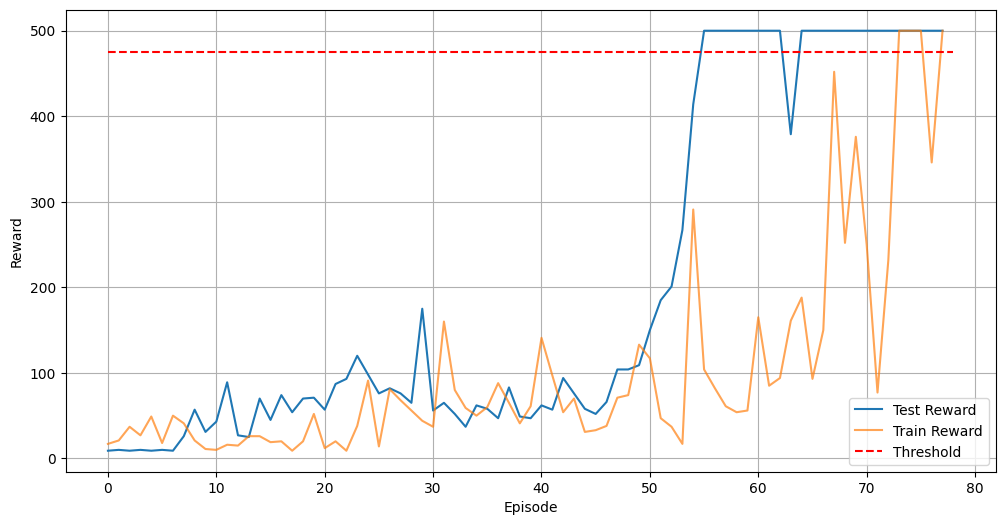

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(test_rewards, label="Test Reward")
plt.plot(train_rewards, label="Train Reward", alpha=0.7)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.hlines(REWARD_THRESHOLD, 0, len(test_rewards), color="red", linestyle="--", label="Threshold")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


## 16) Plot Loss

The loss in policy gradient methods is not as easy to interpret as supervised learning loss.

In supervised learning, lower loss usually clearly means better predictions.

In REINFORCE, the loss depends on sampled actions and returns, so it can bounce around. Reward is usually the metric you care about most.


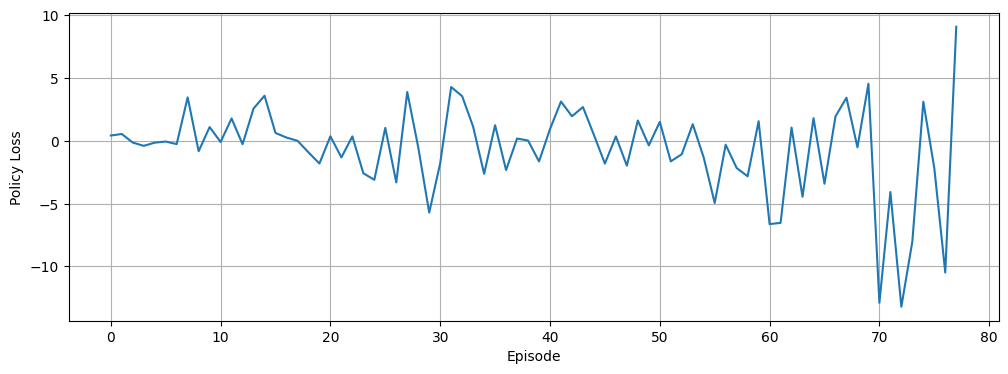

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(losses)
plt.xlabel("Episode")
plt.ylabel("Policy Loss")
plt.grid(True)
plt.show()


## 17) Visualize the Policy in a Window

To open an actual CartPole window, create a separate environment with:

```python
render_mode="human"
```

Keep this separate from training because rendering slows training down a lot.

This cell evaluates the current policy visually. If you run it before training, you will see an untrained policy. If you run it after the training loop, you should see the learned policy.

Important notes:

- This opens a GUI window on machines that support desktop rendering.
- In a remote/headless environment, this may fail because there is no display server.
- Always call `env.close()` when finished.


In [32]:
def watch_policy(policy, seed=SEED, max_steps=500):
    render_env = gym.make("CartPole-v1", render_mode="human")

    state, info = render_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            logits = policy(state_tensor)
            action = torch.argmax(logits, dim=-1).item()

        state, reward, terminated, truncated, info = render_env.step(action)
        total_reward += reward
        steps += 1

    print(f"Episode finished. Total reward: {total_reward}, steps: {steps}")
    render_env.close()


# Run this after training if you want to watch the learned policy.
watch_policy(policy)


Episode finished. Total reward: 500.0, steps: 500


## 18) Exercises

Use these to check whether Lesson 1 actually clicked.

Each prompt has a code cell directly underneath it. Fill in the TODOs and run the cell.


### Exercise 1: Random vs Policy

Write a function called `evaluate_random_policy(env, n_episodes)` that runs random CartPole actions for several episodes and returns the average reward.

Compare it to the trained policy's average reward.

Questions:

- Which one performs better?
- Why is the trained policy better than random actions?


In [62]:
# # TODO: run evaluate_random_policy(test_env, n_episodes=10)
# # TODO: compare against np.mean(test_rewards[-10:]) after training
# # TODO: write your answer in comments below

def evaluate_random_policy(env, n_episodes=10, seed=SEED):
    reward_per_episode = []

    for episode in range(n_episodes):
        state, info = env.reset(seed=seed + episode)
        terminated = False
        truncated = False
        episode_reward = 0.0

        while not (terminated or truncated):
            action = env.action_space.sample()
            next_state, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            state = next_state

        reward_per_episode.append(episode_reward)
    
    return np.mean(reward_per_episode)

random_avg = evaluate_random_policy(test_env, n_episodes=10)
trained_avg = np.mean(test_rewards[-10:])

print("random average:", random_avg)
print("trained average:", trained_avg)


#random average: 14.6
#trained average: 500.0


random average: 21.7
trained average: 500.0


### Exercise 2: Inspect Action Probabilities

Pick one CartPole state and print the policy probabilities.

Questions:

- Which action has higher probability?
- Does the policy seem confident or uncertain?


In [ ]:
state, info = test_env.reset(seed=123)
state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

with torch.no_grad():
    logits = policy(state_tensor)
    # TODO: convert logits to probabilities with torch.softmax
    pass

# TODO: print the original state
# TODO: print logits
# TODO: print probabilities
# TODO: write your answer in comments below


### Exercise 3: Change `gamma`

Try changing:

```python
DISCOUNT_FACTOR = 0.95
DISCOUNT_FACTOR = 0.99
```

You can rerun training with each value.

Questions:

- Does training become faster or slower?
- Does it become more or less stable?
- Why might future rewards matter a lot in CartPole?


In [ ]:
# TODO: choose a new discount factor
experiment_discount_factor = 0.95

# TODO: reinitialize a fresh policy and optimizer
# experiment_policy = PolicyNetwork(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM).to(device)
# experiment_policy.apply(init_weights)
# experiment_optimizer = optim.Adam(experiment_policy.parameters(), lr=LEARNING_RATE)

# TODO: train for a smaller number of episodes, such as 100
# TODO: track rewards and compare with the original run
# TODO: write your observations in comments below


### Exercise 4: Sampling vs Argmax

In `evaluate`, we used:

```python
action = torch.argmax(logits, dim=-1).item()
```

Now write an evaluation function that samples from `Categorical(logits=logits)` instead.

Question:

- Is evaluation more consistent with argmax or sampling?


In [ ]:
def evaluate_with_sampling(env, policy, seed=None):
    policy.eval()

    episode_reward = 0.0
    state, info = env.reset(seed=seed)
    terminated = False
    truncated = False

    while not (terminated or truncated):
        state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            # TODO: get logits from policy
            # TODO: create Categorical(logits=logits)
            # TODO: sample action
            pass

        # TODO: step environment with sampled action
        # TODO: add reward to episode_reward

    return episode_reward


# TODO: run evaluate_with_sampling several times
# TODO: compare the results to evaluate(test_env, policy, seed=...)
# TODO: write your answer in comments below


### Exercise 5: Explain the Loss

In your own words, explain this line:

```python
loss = -(returns * log_probs).sum()
```

Your explanation should include:

- why `returns` are used
- why `log_probs` are used
- why there is a negative sign


In [ ]:
# TODO: Write your explanation as comments.

# returns:

# log_probs:

# negative sign:

# full explanation:


## 19) Lesson 1 Mental Model

REINFORCE replaces random actions with sampled policy actions.

The data flow is:

```text
state -> policy network -> action logits -> Categorical distribution -> sampled action
sampled action -> env.step(action) -> reward + next state
episode rewards -> returns
returns + log probabilities -> policy loss
loss.backward() -> policy improves
```

Key ideas:

- the policy outputs action preferences
- `Categorical` turns action preferences into a sampleable distribution
- `log_prob(action)` records how likely the chosen action was
- returns estimate how good each action turned out to be
- high-return actions are pushed to become more likely
- low-return actions are pushed to become less likely

REINFORCE is simple and important, but noisy. Later algorithms add value functions and advantage estimates to reduce that noise.
